# **DX 799: Week 4 — Decision Trees and Random Forests**

For Week 6, include concepts such as decision trees and random forests. Complete your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In [6]:
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold, cross_val_score, train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.tree            import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics         import mean_absolute_error
from sklearn.ensemble       import RandomForestRegressor
from scipy.stats import randint
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")
# globals

random_seed = 42

pd.set_option('display.max_columns', None)

---

# DIABETES DATASET

In [7]:
#DIABETES: LOAD
df_diabetes = pd.read_csv("../Datasets/diabetes_cleaned.csv")
# The first few rows
df_diabetes.iloc[0:5]

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [8]:
#DIABETES: SPLIT
df_diabetes = pd.read_csv("../Datasets/diabetes_cleaned.csv")

X = df_diabetes.drop(columns="Diabetes_012")
y = df_diabetes["Diabetes_012"]

random_seed = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed, stratify=y
)
print(f"Train shape: {X_train.shape},  Test shape: {X_test.shape}")

Train shape: (202944, 21),  Test shape: (50736, 21)


In [10]:
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

# ------------------------
# 2. DECISION TREE CLASSIFIER
# ------------------------
def run_decision_tree_classifier(X_train, y_train, visualize=False,
                                 max_depth=None, min_samples_split=2,
                                 min_samples_leaf=1, random_state=42, n_jobs=-1):
    """
    Runs a Decision Tree Classifier with repeated cross-validation.
    Prints the average accuracy.
    """
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state
    )

    # Cross-validated accuracy
    acc_scores = cross_val_score(model, X_train, y_train,
                                 scoring='accuracy', cv=repeated_cv, n_jobs=n_jobs)
    mean_acc = np.mean(acc_scores)
    print(f"Decision Tree - Mean CV Accuracy: {mean_acc:.4f}")

    # Optional visualization
    if visualize:
        model = DecisionTreeClassifier(max_depth=3, random_state=random_state)
        model.fit(X_train, y_train)
        plt.figure(figsize=(12, 6))
        plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True)
        plt.title("Simplified Decision Tree (max_depth=3)")
        plt.show()


    return mean_acc



===== Decision Tree (Default) =====
Decision Tree - Mean CV Accuracy: 0.7672


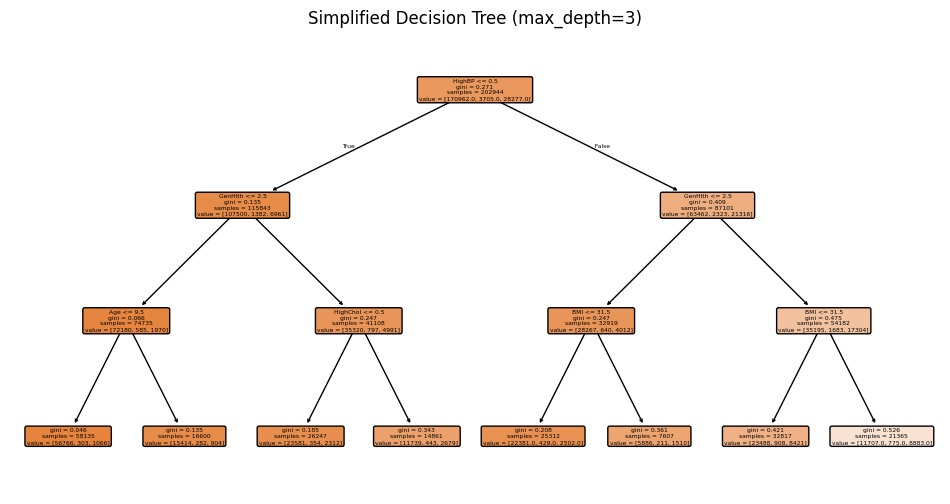

In [11]:
print("\n===== Decision Tree (Default) =====")
dt_acc = run_decision_tree_classifier(X_train, y_train, visualize=True)

The decision tree classifier achieved a mean cross-validated accuracy of 0.7672, indicating that the model correctly predicts diabetes status about 77% of the time on average across validation folds.

The initial full-depth tree was highly complex, showing signs of overfitting. To make the model easier to interpret, a simplified version was visualized with a maximum depth of three levels.

From the simplified decision tree, the most influential predictors for diabetes were High Blood Pressure (HighBP), General Health (GenHlth), and Body Mass Index (BMI). These features appear frequently near the top of the tree, suggesting they provide the most informative splits in the dataset.

In [12]:

# ------------------------
# 3. RANDOM FOREST CLASSIFIER
# ------------------------
def run_random_forest_classifier(X_train, y_train,
                                 n_estimators=100, max_depth=None,
                                 random_state=42, n_jobs=-1):
    """
    Runs a Random Forest Classifier with repeated cross-validation.
    Prints the average accuracy.
    """
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        n_jobs=n_jobs
    )

    acc_scores = cross_val_score(model, X_train, y_train,
                                 scoring='accuracy', cv=repeated_cv, n_jobs=n_jobs)
    mean_acc = np.mean(acc_scores)
    print(f"Random Forest - Mean CV Accuracy: {mean_acc:.4f}")

    return mean_acc


In [13]:
print("\n===== Random Forest (Default) =====")
rf_acc = run_random_forest_classifier(X_train, y_train)



===== Random Forest (Default) =====
Random Forest - Mean CV Accuracy: 0.8418


The Random Forest classifier achieved a mean cross-validated accuracy of 0.8418, showing a noticeable improvement compared to the single Decision Tree model (0.7672). This suggests that the ensemble approach provided better generalization and reduced overfitting.

Random Forest works by combining predictions from multiple decision trees, each trained on random subsets of data and features. This reduces variance and helps capture more stable, reliable patterns in the dataset. The model’s higher accuracy indicates that it effectively balanced complexity and interpretability while improving predictive performance.

🔍 Model Comparison: Decision Tree vs Random Forest

Both models performed well in predicting diabetes outcomes, but the Random Forest model (CV Accuracy = 0.8418) outperformed the single Decision Tree (CV Accuracy = 0.7672).
While the Decision Tree provided a clear visual understanding of key predictors such as High Blood Pressure (HighBP), General Health (GenHlth), and BMI, it showed signs of overfitting when grown without constraints.
The Random Forest model, by averaging results from many trees, reduced overfitting and captured more stable patterns across the data, making it a stronger and more reliable predictive model overall.

---
# KIDNEY DATASET 

In [14]:
#Kidney: LOAD
df_kidney = pd.read_csv("../Datasets/Chronic_Kidney_Dsease_data.csv")
# The first few rows
df_kidney.iloc[0:5]

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryKidneyDisease,FamilyHistoryHypertension,FamilyHistoryDiabetes,PreviousAcuteKidneyInjury,UrinaryTractInfections,SystolicBP,DiastolicBP,FastingBloodSugar,HbA1c,SerumCreatinine,BUNLevels,GFR,ProteinInUrine,ACR,SerumElectrolytesSodium,SerumElectrolytesPotassium,SerumElectrolytesCalcium,SerumElectrolytesPhosphorus,HemoglobinLevels,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,ACEInhibitors,Diuretics,NSAIDsUse,Statins,AntidiabeticMedications,Edema,FatigueLevels,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,0.240386,4.076434,0,0,0,0,0,113,83,72.510788,9.212397,4.962531,25.605949,45.703204,0.744980,123.849426,137.652501,3.626058,10.314420,3.152648,16.114679,207.728670,85.863656,21.967957,212.095215,0,0,4.563139,1,0,0,3.563894,6.992244,4.518513,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,6.503233,7.652813,1,1,0,0,0,120,67,100.848875,4.604989,3.156799,31.338166,55.784504,3.052317,88.539095,138.141335,5.332871,9.604196,2.855443,15.349205,189.450727,86.378670,87.569756,255.451314,0,0,9.097002,0,0,0,5.327336,0.356290,2.202222,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,2.104828,4.392786,0,0,0,0,0,147,106,160.989441,5.432599,3.698236,39.738169,67.559032,1.157839,21.170892,142.970116,4.330891,9.885786,4.353513,13.018834,284.137622,132.269872,20.049798,251.902583,0,1,3.851249,1,0,0,4.855420,4.674069,5.967271,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,6.964422,6.282274,0,0,0,0,0,117,65,188.506620,4.144466,2.868468,21.980958,33.202542,3.745871,123.779699,137.106913,3.810741,9.995894,4.016134,15.056339,235.112124,93.443669,58.260291,392.338425,0,0,7.881765,0,0,0,8.531685,5.691455,2.176387,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,3.097796,4.021639,0,0,0,0,0,98,66,82.156699,4.262979,3.964877,12.216366,56.319082,2.570993,184.852046,140.627812,4.866765,8.907622,3.947907,16.690561,258.277566,171.758356,21.583213,370.523877,1,1,4.179459,1,0,0,1.422320,2.273459,6.800993,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


In [18]:
# KIDNEY: SPLIT
df_kidney = pd.read_csv("../Datasets/Chronic_Kidney_Dsease_data.csv")

X_kidney = df_kidney.drop(columns=["Diagnosis", "DoctorInCharge"])
y_kidney = df_kidney["Diagnosis"]

random_seed = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_kidney, y_kidney, test_size=0.2, random_state=random_seed, stratify=y_kidney
)
print(f"Train shape: {X_train.shape},  Test shape: {X_test.shape}")


Train shape: (1327, 52),  Test shape: (332, 52)


In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import RepeatedKFold, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

cv_kidney = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

decision_tree = DecisionTreeClassifier(random_state=random_seed)
acc_scores = cross_val_score(decision_tree, X_train, y_train,
                             scoring="accuracy", cv=cv_kidney)
print("===== Decision Tree (Default) =====")
print(f"Decision Tree - Mean CV Accuracy: {np.mean(acc_scores):.4f}")


===== Decision Tree (Default) =====
Decision Tree - Mean CV Accuracy: 0.9127


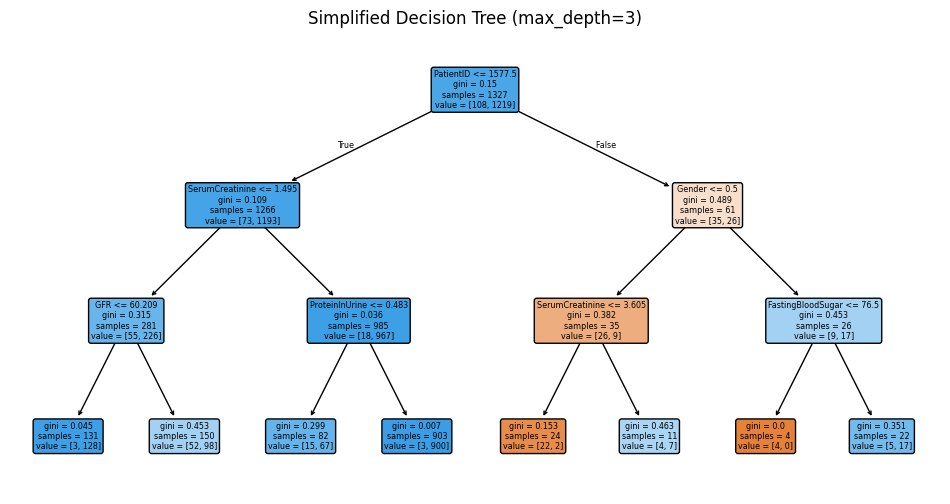

In [20]:
model = DecisionTreeClassifier(max_depth=3, random_state=random_seed)
model.fit(X_train, y_train)
plt.figure(figsize=(12,6))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Simplified Decision Tree (max_depth=3)")
plt.show()


📝 Decision Tree Results – Kidney Dataset

The decision tree classifier achieved a mean cross-validated accuracy of 0.9127, indicating strong model performance on the kidney disease dataset.
The simplified tree visualization (max_depth = 3) shows that Serum Creatinine, Glomerular Filtration Rate (GFR), and Protein in Urine were the most important predictors for diagnosing kidney disease.
These top-level splits align with known clinical indicators, as higher creatinine levels and lower GFR values typically suggest reduced kidney function.

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_kidney = RandomForestClassifier(random_state=random_seed)
rf_scores = cross_val_score(rf_kidney, X_train, y_train,
                            scoring="accuracy", cv=cv_kidney)
print("===== Random Forest (Default) =====")
print(f"Random Forest - Mean CV Accuracy: {np.mean(rf_scores):.4f}")


===== Random Forest (Default) =====
Random Forest - Mean CV Accuracy: 0.9188


📝 Random Forest Results – Kidney Dataset

The Random Forest model achieved a slightly higher mean cross-validated accuracy of 0.9188, showing an improvement over the single decision tree.
By aggregating the results of many individual trees, the Random Forest reduced variance and improved generalization.
This suggests that ensemble learning captured a more complete pattern of risk factors for kidney disease while maintaining high accuracy and stability.

🔍 Model Comparison: Decision Tree vs Random Forest

Both models performed very well on the kidney dataset, but the Random Forest (Accuracy = 0.9188) slightly outperformed the Decision Tree (Accuracy = 0.9127).
The decision tree offered interpretability, highlighting Serum Creatinine and GFR as key features, while the Random Forest provided better predictive reliability.
Overall, the Random Forest’s ensemble structure makes it the stronger model for identifying kidney disease risk patterns while reducing overfitting.

---

# HYPERTENSION DATASET

In [22]:
#HYPERTENSION: LOAD
df_hypertension = pd.read_csv("../Datasets/df_hypertension_clean.csv")
# The first few rows
df_hypertension.iloc[0:5]

,Country,Age,BMI,Cholesterol,Systolic_BP,Diastolic_BP,Smoking_Status,Alcohol_Intake,Physical_Activity_Level,Family_History,Diabetes,Stress_Level,Salt_Intake,Sleep_Duration,Heart_Rate,LDL,HDL,Triglycerides,Glucose,Gender,Education_Level,Employment_Status,Hypertension
0,UK,58,29.5,230,160,79,Never,27.9,Low,1,1,9,14.7,6.1,80,100,75,72,179,Female,Primary,Unemployed,1
1,Spain,34,36.2,201,120,84,Never,27.5,High,1,1,6,10.8,9.8,56,77,47,90,113,Male,Secondary,Unemployed,1
2,Indonesia,73,18.2,173,156,60,Current,1.8,High,1,1,5,6.5,5.2,75,162,56,81,101,Male,Primary,Employed,0
3,Canada,60,20.3,183,122,94,Never,11.6,Moderate,1,1,6,4.0,7.5,71,164,93,94,199,Female,Secondary,Retired,1
4,France,73,21.8,296,91,97,Never,29.1,Moderate,1,0,6,8.4,5.0,52,108,74,226,157,Female,Primary,Employed,1


In [23]:
# HYPERTENSION: LOAD
df_hypertension = pd.read_csv("../Datasets/df_hypertension_clean.csv")

# One-hot encode categorical columns
obj_cols = df_hypertension.select_dtypes(include="object").columns.tolist()
df_hyp_enc = pd.get_dummies(df_hypertension, columns=obj_cols, drop_first=True)

# Define features and target
y_hyp = df_hyp_enc["Hypertension"]
X_hyp = df_hyp_enc.drop("Hypertension", axis=1)

# Train/test split
random_seed = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_hyp, y_hyp, test_size=0.2, random_state=random_seed, stratify=y_hyp
)
print(f"Train shape: {X_train.shape},  Test shape: {X_test.shape}")


Train shape: (139985, 44),  Test shape: (34997, 44)


In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import RepeatedKFold, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

cv_hyp = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

# Base Decision Tree model
decision_tree_hyp = DecisionTreeClassifier(random_state=random_seed)
acc_scores = cross_val_score(decision_tree_hyp, X_train, y_train,
                             scoring="accuracy", cv=cv_hyp)
print("===== Decision Tree (Default) =====")
print(f"Decision Tree - Mean CV Accuracy: {np.mean(acc_scores):.4f}")


===== Decision Tree (Default) =====
Decision Tree - Mean CV Accuracy: 0.5874


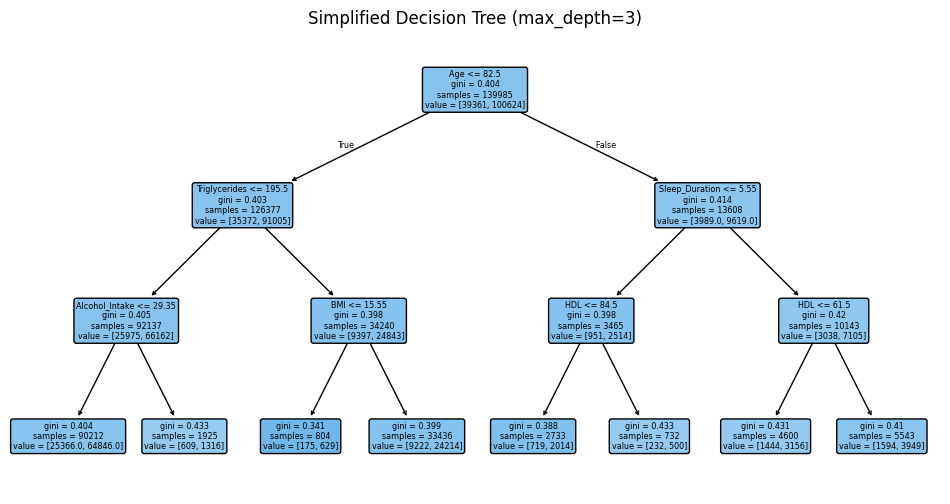

In [25]:
model = DecisionTreeClassifier(max_depth=3, random_state=random_seed)
model.fit(X_train, y_train)
plt.figure(figsize=(12,6))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Simplified Decision Tree (max_depth=3)")
plt.show()


📝 Decision Tree Results – Hypertension Dataset

The decision tree classifier achieved a mean cross-validated accuracy of 0.5874, indicating moderate predictive performance on the hypertension dataset.
The simplified tree (max_depth = 3) highlights Age, Triglycerides, and Sleep Duration as the most influential predictors for hypertension classification.
These results suggest that lifestyle and biological factors—particularly age, lipid levels, and sleep patterns—play a significant role in determining hypertension risk.



In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_hyp = RandomForestClassifier(random_state=random_seed)
rf_scores = cross_val_score(rf_hyp, X_train, y_train,
                            scoring="accuracy", cv=cv_hyp)
print("===== Random Forest (Default) =====")
print(f"Random Forest - Mean CV Accuracy: {np.mean(rf_scores):.4f}")


===== Random Forest (Default) =====
Random Forest - Mean CV Accuracy: 0.7187


📝 Random Forest Results – Hypertension Dataset

The Random Forest model achieved a mean cross-validated accuracy of 0.7187, showing a clear improvement over the single decision tree.
By aggregating multiple trees, the Random Forest reduced overfitting and captured more generalizable patterns in the data.
This improvement suggests that ensemble learning is more effective for modeling the complex relationships between demographic, health, and lifestyle variables associated with hypertension.



🔍 Model Comparison: Decision Tree vs Random Forest

The Random Forest (Accuracy = 0.7187) outperformed the Decision Tree (Accuracy = 0.5874), demonstrating that ensemble methods provide better generalization for predicting hypertension.
While the decision tree offers interpretability—showing that age, triglycerides, and sleep duration were key features—the Random Forest provided stronger overall accuracy and model stability.
This result reinforces the advantage of ensemble approaches in handling multifactorial health conditions like hypertension, where multiple variables interact in complex ways.